# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import gc
import os
import sys
import random
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import fvdb_utils as fu
import model as fvdbModel
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure

# Args

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'

# EDA

## Analysis SDF

In [3]:
sdf1, sdf2 = get_item(sdf_nmc_dir, '00000015.hdf5')

In [4]:
sdf1.shape, sdf2.shape

((33, 33, 33), (65, 65, 65))

In [5]:
# dir = '/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/data'
# v, f = igl.read_triangle_mesh(os.path.join(dir, '00000008_9b3d6a97e8de4aa193b81000_trimesh_000.obj'))

In [6]:
# plot(v,f)

In [7]:
verts, faces, normals, values = measure.marching_cubes(sdf1, level=0)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(16.012687…

In [8]:
mt.plotSlice(sdf2, 0.1)


interactive(children=(IntSlider(value=32, description='s', max=64), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [9]:
mt.plotSlice(sdf2*mt.make_mask_close(sdf2, 65), 0.1)

interactive(children=(IntSlider(value=32, description='s', max=64), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

## Display effect of scale

In [10]:
small_vdb, large_vdb = fu.sdf_to_vdb(sdf1, sdf2, mt.make_mask_close(sdf1, 33), size=33)

`Without scaling the input`

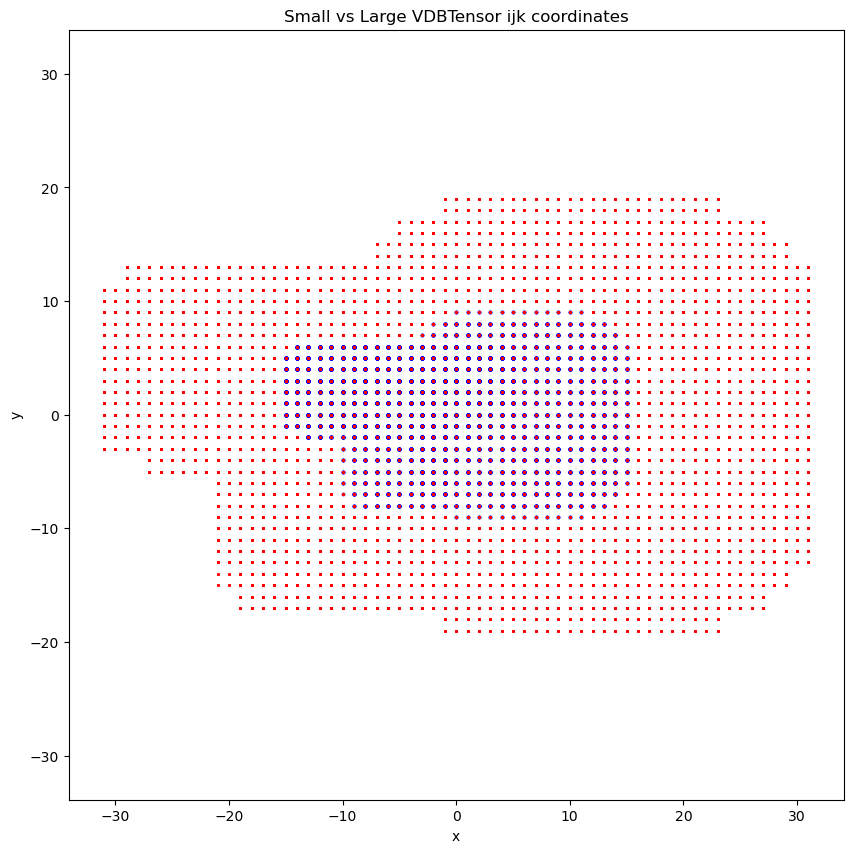

In [11]:
# plot the co-ordinates ijk of the small VDBTensor
plt.figure(figsize=(10, 10))
plt.scatter(small_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), small_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=3, c='b')
plt.scatter(large_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), large_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=1, c='r')
plt.title('Small vs Large VDBTensor ijk coordinates')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

`Scaled by 2`

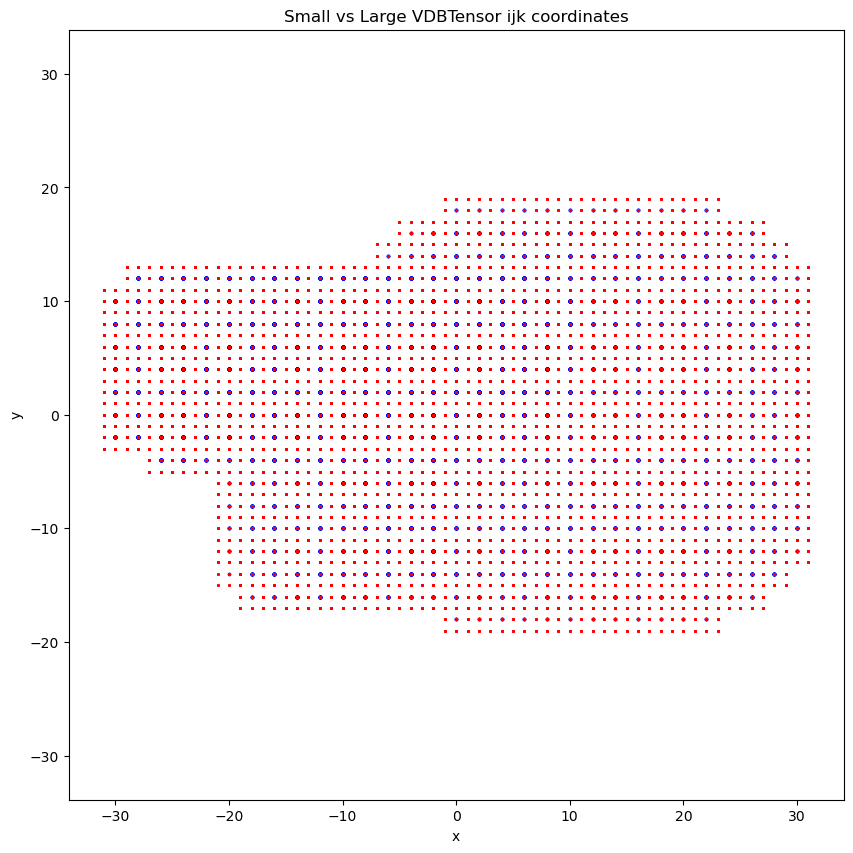

In [12]:
# plot the co-ordinates ijk of the small VDBTensor
plt.figure(figsize=(10, 10))
plt.scatter(2*small_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), 2*small_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=3, c='b')
plt.scatter(large_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), large_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=1, c='r')
plt.title('Small vs Large VDBTensor ijk coordinates')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

# Load Dataset

In [13]:
with open('../data_utils/abc_watertight_train.txt', 'r') as f:
    train_set_names = [e[:-1] for e in f.readlines()]
train_set_names = train_set_names[:150]

In [14]:
random.shuffle(train_set_names)
train_size = int(0.6 * len(train_set_names))
test_size = int(0.2 * len(train_set_names))
val_size = len(train_set_names) - train_size - test_size
train_names = train_set_names[:train_size]
val_names = train_set_names[train_size:train_size + val_size]
test_names = train_set_names[train_size + val_size:]

train_dataset = ABCdataset(sdf_nmc_dir, train_names)
val_dataset = ABCdataset(sdf_nmc_dir, val_names)
test_dataset = ABCdataset(sdf_nmc_dir, test_names, mode='test')

print(f'Number of samples in the dataset: {len(train_set_names)}')
print(f'Number of samples in the train set: {len(train_dataset)}')
print(f'Number of samples in the test set: {len(test_dataset)}')
print(f'Number of samples in the validation set: {len(val_dataset)}')

100%|██████████| 90/90 [00:00<00:00, 18618.37it/s]


100%|██████████| 30/30 [00:00<00:00, 16955.82it/s]

Number of samples in the dataset: 150
Number of samples in the train set: 90
Number of samples in the test set: 30
Number of samples in the validation set: 30


In [15]:
# %reload_ext autoreload
train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')

# Train Model

In [16]:
print('TODO:  \n - check that the transposed conv is correct \n - add/remove layers \n - add MaxPool to be invariant to sparse grid activations?')

TODO:  
 - check that the transposed conv is correct 
 - add/remove layers 
 - add MaxPool to be invariant to sparse grid activations?


`Position Encoding`

In [17]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

`Without Scaling`

In [18]:
pos_enc_dim = 10
model = fvdbModel.CNN_vanilla(in_channels=pos_enc_dim+1, features=128, out_channels=1)
model = model.to(device)

`Other Param`

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

`Training`

In [20]:
def train(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            large_vdb = large_vdb.to(device)
            
            optimizer.zero_grad()
            out = model(small_vdb, large_vdb.grid)
            loss = criterion(out.jdata, large_vdb.data.jdata)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                small_vdb = positional_encoding(small_vdb.to(device), pos_enc_dim)
                large_vdb = large_vdb.to(device)
                out = model(small_vdb, large_vdb.grid)
                loss = criterion(out.jdata, large_vdb.data.jdata)
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        history.append(Loss)

    return history

In [21]:
gc.collect()
torch.cuda.empty_cache()

In [22]:
history = train(model, 
                train_data_loader, 
                val_data_loader, 
                optimizer, 
                criterion, 
                epochs=5, 
                device=device)

Epoch 1/5: 100%|██████████| 90/90 [00:09<00:00,  9.99it/s]


Epoch 1/5, Loss: 1.2743


Validation: 100%|██████████| 30/30 [00:02<00:00, 13.55it/s]


Validation Loss: 0.3716


Epoch 2/5: 100%|██████████| 90/90 [00:08<00:00, 10.31it/s]


...

Validation Loss: 0.0367


Epoch 5/5: 100%|██████████| 90/90 [00:08<00:00, 10.87it/s]


Epoch 5/5, Loss: 0.0455


Validation: 100%|██████████| 30/30 [00:02<00:00, 12.24it/s]

Validation Loss: 0.0291


`Plot history`

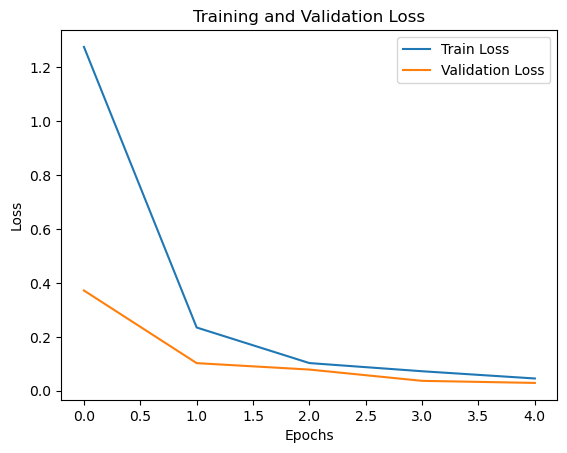

In [23]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

`Without Transposed`

In [ ]:
# values = np.zeros((4,4))
# values[[1,2],[1,1]] = np.array([[1], [2]]).squeeze()
# ijk = np.array([[0, 0], [1, 1], [2, 1], [3, 3]])
# values = values[ijk[:, 0], ijk[:, 1]]
# values[:, None]

In [ ]:
# values = new_vdb.data.jdata.cpu().numpy()
# mt.plotSlice(values, 0.1)

In [ ]:
ijk = small_vdb.grid.ijk.jdata.cpu().numpy()
ijk[:,0]

array([-15, -15, -15, ...,   3,   3,   3], shape=(5464,), dtype=int32)

In [ ]:
# import matplotlib.pyplot as plt

# fig = plt.figure(figsize=(5, 5))
# ax = fig.add_subplot(111, projection='3d')
# ax.voxels(values, facecolors=plt.cm.viridis(values/values.max()), edgecolor='k')
# plt.title('3D Voxels')
# plt.show()

In [ ]:
# new_vdb = subdivide_and_map_vdb(small_vdb)

In [29]:
# def subdivide_and_map_vdb(vdb, factor=2):
#     vdb_ijk = vdb.grid.ijk.jdata.cpu().numpy()
#     vdb_ijk = vdb_ijk * factor
#     vdb_ijk_tensor = torch.tensor(vdb_ijk, dtype=torch.int32, device=vdb.grid.ijk.device)
#     vdb_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(vdb_ijk_tensor),
#                                        origins=vdb.grid.origins,
#                                        voxel_sizes=vdb.grid.voxel_sizes)
#     new_vdb = fvnn.VDBTensor(vdb_grid, vdb.grid.jagged_like(vdb.data.jdata))
#     return new_vdb
def subdivide_and_map_vdb(small_vdb, shape=(65, 65, 65)):
    # custom_grid = fu.custom_subdivide_grid(small_vdb.grid)
    ijk = small_vdb.grid.ijk.jdata.cpu().numpy()
    values = small_vdb.data.jdata.cpu().numpy()

    ijk_tensor = torch.tensor(ijk, device=device)
    values_tensor = torch.tensor(values, device=device).flatten()  # (N,)

    # Create the mesh grid offsets (M, 3)
    m3g = torch.tensor(mt.mesh_grid(3), device=device) - 1  # (M, 3)
    M = m3g.shape[0]
    N = ijk_tensor.shape[0]

    # Expand ijk and offsets for broadcasting
    ijk_expanded = ijk_tensor.unsqueeze(1).expand(N, M, 3)  # (N, M, 3)
    m3g_expanded = m3g.unsqueeze(0).expand(N, M, 3)         # (N, M, 3)

    # Compute new ijk values
    new_ijk = 2 * ijk_expanded + m3g_expanded               # (N, M, 3)
    new_ijk = new_ijk.reshape(-1, 3)                        # (N*M, 3)

    # Repeat values for each offset
    new_values = values_tensor.unsqueeze(1).expand(N, M).reshape(-1, 1)

    # Remove duplicate indices and keep only unique ones
    new_ijk_np = new_ijk.cpu().numpy()
    new_values_np = new_values.cpu().numpy()

    # Find unique indices and their first occurrence
    unique_ijk, unique_indices = np.unique(new_ijk_np, axis=0, return_index=True)

    # Select corresponding values
    unique_values = new_values_np[unique_indices]

    # Convert back to torch tensors
    unique_ijk_tensor = torch.tensor(unique_ijk, dtype=ijk_tensor.dtype, device=ijk.device)
    unique_values_tensor = torch.tensor(unique_values, dtype=values_tensor.dtype, device=ijk.device)

    # Now create the grid and VDBTensor
    new_grid = fvdb.gridbatch_from_ijk(
        fvdb.JaggedTensor(unique_ijk_tensor),
        origins=small_vdb.grid.origins,
        voxel_sizes=small_vdb.grid.voxel_sizes
    )
    new_vdb = fvnn.VDBTensor(
        new_grid,
        new_grid.jagged_like(unique_values_tensor)
)
    
    return new_vdb


#     new_values = []
#     new_ijk = []
    
#     for ijk_val, value in zip(ijk, values):
#         ijk_val = torch.tensor(ijk_val, device=device)
        
#         m3g = torch.tensor(mt.mesh_grid(3),device=device)-1
#         values = torch.full((len(m3g),), value[0], device=device, dtype=torch.float32)
#         values = values[:, None]
#         ijk_val = (2*ijk_val + m3g)
#         new_values.append(values)
#         new_ijk.append(ijk_val)
        
        
#     new_values = torch.cat(new_values, dim=0, device=ijk.device)
#     new_ijk = torch.cat(new_ijk, dim=0, device=ijk.device) 

#     shape_tensor = torch.tensor(shape, device=ijk.device)
#     ijk_clipped = torch.minimum(
#     torch.maximum(new_ijk, torch.zeros_like(new_ijk, device=ijk.device)),
#     (shape_tensor - 1)
# )
#     return new_values.shape, ijk_clipped.shape

    # Remove duplicate indices
    # ijk_custom = np.unique(ijk_custom, axis=0)
    # values = np.zeros(len(ijk_custom), dtype=np.float32)

    # # Build a mapping from tuple to index for ijk_custom
    # ijk_custom_dict = {tuple(row): idx for idx, row in enumerate(ijk_custom)}

    # # Compute all new_ijk at once
    # new_ijk = ijk * 2  # shape (N, 3)

    # for idx, row in enumerate(new_ijk):
    #     key = tuple(row)
    #     if key in ijk_custom_dict:
    #         i = ijk_custom_dict[key]
    #         values[i] = small_vdb.jdata[idx].cpu().numpy()

    # values_tensor = torch.tensor(values, device=small_vdb.jdata.device).unsqueeze(-1)
    # new_small_vdb = fvnn.VDBTensor(custom_grid, custom_grid.jagged_like(values_tensor))
    # return new_small_vdb

In [30]:
import joblib
class WithoutTransposeDataLoader(torch.utils.data.Dataset):
    def __init__(self, src_dir, names_set, mode='train'):
        self.grid_n = 33
        self.mode = mode
        self.names_set = names_set
        
        out = joblib.Parallel(n_jobs=-1)(joblib.delayed(get_item)
                                             (src_dir, model_name) for model_name in tqdm(names_set))
        # Filter out None values
        self.out = [self.sub_process(sdf, out_sdf) for sdf, out_sdf in out if sdf is not None and out_sdf is not None]
        if len(out) == 0:
            raise ValueError("No valid SDF data found in the provided dataset.")
        
        # extract SDFs
        # self.sdfs = [e[0] for e in out]
        # self.out_sdfs = [e[1] for e in out]

    def sub_process(self, sdf, out_sdf):
        mask = mt.make_mask_close(sdf, self.grid_n)
        sdf_vdb, out_sdf_vdb = fu.sdf_to_vdb(sdf, 
                                                out_sdf, 
                                                mask=mask, 
                                                size=self.grid_n)
        
        sdf_vdb_input = subdivide_and_map_vdb(sdf_vdb)
        sdf_vdb_input = positional_encoding(sdf_vdb_input.to(device), pos_enc_dim)
        return sdf_vdb, sdf_vdb_input, out_sdf_vdb
    
    def __len__(self):
        return len(self.names_set)

    def __getitem__(self, index):
        if self.mode != 'test': 
            # sdf = self.sdfs[index]
            # out_sdf = self.out_sdfs[index]
            # todo: automate the grid_n value
            sdf_vdb, sdf_vdb_input, out_sdf_vdb = self.out[index]
            # small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            return sdf_vdb_input, out_sdf_vdb
        else:
            # sdf = self.sdfs[index]
            # out_sdf = self.out_sdfs[index]
            # todo: automate the grid_n value
            sdf_vdb, sdf_vdb_input, out_sdf_vdb = self.out[index]

            # small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            return sdf_vdb, sdf_vdb_input, out_sdf_vdb

In [31]:
def custom_collate_fn(batch):
    # batch is a list of tuples: [(small_vdb, large_vdb), ...]
    small_vdbs, large_vdbs = zip(*batch)
    # Move each VDBTensor to device if needed
    small_vdbs = [vdb.to(device) for vdb in small_vdbs]
    large_vdbs = [vdb.to(device) for vdb in large_vdbs]
    return small_vdbs[0], large_vdbs[0]

In [32]:
train_data_loader_without_transpose = torch.utils.data.DataLoader(
    WithoutTransposeDataLoader(sdf_nmc_dir, train_names, mode='train'),
    batch_size=1, shuffle=True, num_workers=0, collate_fn=custom_collate_fn)
val_data_loader_without_transpose = torch.utils.data.DataLoader(
    WithoutTransposeDataLoader(sdf_nmc_dir, val_names, mode='val'),
    batch_size=1, shuffle=False, num_workers=0, collate_fn=custom_collate_fn)
test_data_loader_without_transpose = torch.utils.data.DataLoader(
    WithoutTransposeDataLoader(sdf_nmc_dir, test_names, mode='test'),
    batch_size=1, shuffle=False, num_workers=0, collate_fn=custom_collate_fn)

100%|██████████| 90/90 [00:00<00:00, 43121.70it/s]


100%|██████████| 30/30 [00:00<00:00, 20757.03it/s]


In [33]:
def train2(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            # print(small_vdb.jdata.shape, large_vdb.data.jdata.shape)
            # small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            small_vdb = small_vdb.to(device)
            large_vdb = large_vdb.to(device)
            
            optimizer.zero_grad()
            out = model(small_vdb, large_vdb.grid)
            loss = criterion(out.jdata, large_vdb.data.jdata)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                # small_vdb = positional_encoding(small_vdb.to(device), pos_enc_dim)
                large_vdb = large_vdb.to(device)
                out = model(small_vdb, large_vdb.grid)
                loss = criterion(out.jdata, large_vdb.data.jdata)
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        history.append(Loss)

    return history

In [34]:
gc.collect()
torch.cuda.empty_cache()

In [35]:
model2 = fvdbModel.CNN_vanilla2(in_channels=pos_enc_dim+1, features=128, out_channels=1)
model2 = model2.to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
history2 = train2(model2, 
                 train_data_loader_without_transpose, 
                 val_data_loader_without_transpose, 
                 optimizer2, 
                 criterion, 
                 epochs=20, 
                 device=device)
plt.plot(history2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

Epoch 1/20:   0%|          | 0/90 [00:00<?, ?it/s]


UnboundLocalError: cannot access local variable 'enc' where it is not associated with a value

`display test sample`

In [24]:
# idx = random.randint(0, len(test_dataset)-1)
idx=0
small_sdf, large_sdf, mask, input, actual = test_dataset[idx]
input = positional_encoding(input, pos_enc_dim).to(device)
actual = actual.to(device)

# large grid from small VDBTensor
small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                      None, 
                                      mask = mask, 
                                      size=33, mode='test')
pred = model(input, large_grid)

In [25]:
v, f = fu.vdb_marching_cubes(small_vdb)
plot(v,f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [26]:
v, f = fu.vdb_marching_cubes(pred)
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001220…

In [27]:
v, f = fu.vdb_marching_cubes(actual)
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

`Without Transpose`

# raugh

[[-15  -9  -2]
 [-15  -9  -1]
 [-14  -9  -3]
 ...
 [ 16   7   2]
 [ 16   8   0]
 [ 16   8   1]]


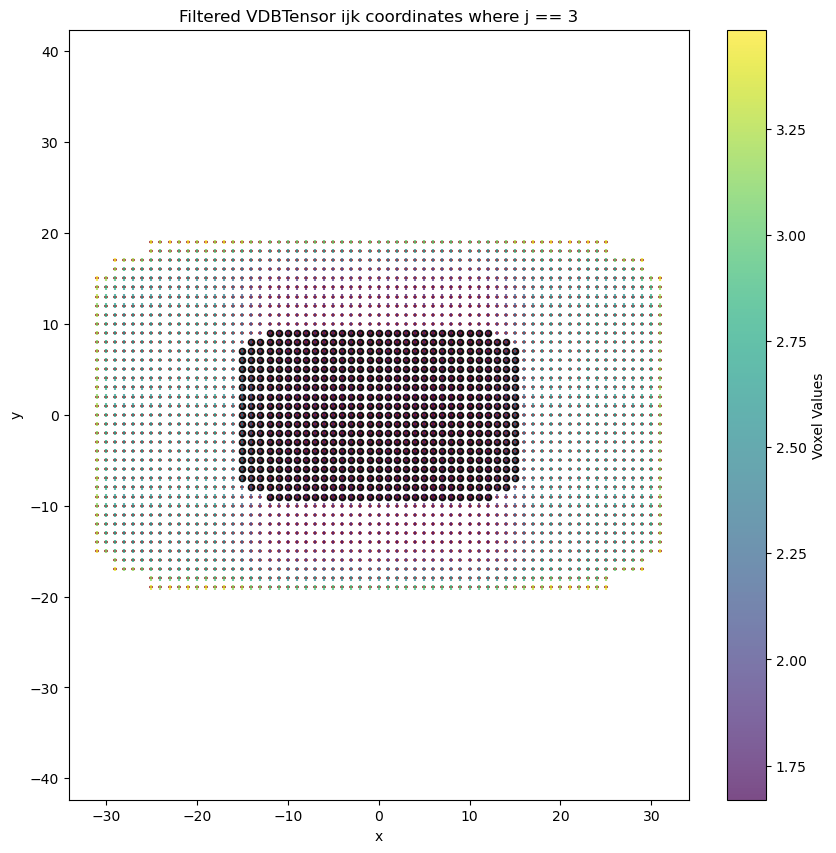

In [56]:
# Get the ijk indices (N, 3)
# small_vdb = input
large_vdb = pred
ijk = small_vdb.grid.ijk.jdata.cpu().numpy()
print(ijk)
# Find indices where j (the second axis) == 2
mask_j2 = (ijk[:, 2] == 3)

# Filter ijk and features
filtered_ijk = ijk[mask_j2]
filtered_features = small_vdb.jdata.cpu().numpy()[mask_j2]

# Create new JaggedTensor and GridBatch
filtered_ijk_tensor = torch.tensor(filtered_ijk, dtype=torch.int32, device=small_vdb.jdata.device)
new_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(filtered_ijk_tensor), 
                                   origins=small_vdb.grid.origins, 
                                   voxel_sizes=small_vdb.grid.voxel_sizes)

# Create new VDBTensor
filtered_features_tensor = torch.tensor(filtered_features, device=small_vdb.jdata.device)
new_vdb = fvnn.VDBTensor(new_grid, new_grid.jagged_like(filtered_features_tensor))





# new vdb 2
new_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(filtered_ijk_tensor*2), 
                                   origins=small_vdb.grid.origins, 
                                   voxel_sizes=small_vdb.grid.voxel_sizes)
filtered_features_tensor = torch.tensor(filtered_features, device=small_vdb.jdata.device)
new_vdb2 = fvnn.VDBTensor(new_grid, new_grid.jagged_like(filtered_features_tensor))


# tranformed small_vdb
transformed_new_vdb = subdivide_and_map_vdb(small_vdb)
ijk = transformed_new_vdb.grid.ijk.jdata.cpu().numpy()
# Find indices where j (the second axis) == 2
mask_j2 = (ijk[:, 2] == 6)

# Filter ijk and features
filtered_ijk = ijk[mask_j2]
filtered_features = transformed_new_vdb.jdata.cpu().numpy()[mask_j2]

# Create new JaggedTensor and GridBatch
filtered_ijk_tensor = torch.tensor(filtered_ijk, dtype=torch.int32, device=small_vdb.jdata.device)
new_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(filtered_ijk_tensor), 
                                   origins=small_vdb.grid.origins, 
                                   voxel_sizes=small_vdb.grid.voxel_sizes)

# Create new VDBTensor
filtered_features_tensor = torch.tensor(filtered_features, device=small_vdb.jdata.device)
transformed_new_vdb = fvnn.VDBTensor(new_grid, new_grid.jagged_like(filtered_features_tensor))





# create a new VDBTensor with the filtered ijk and features for large_vdb
large_ijk = large_vdb.grid.ijk.jdata.cpu().numpy()
mask_j2_large = (large_ijk[:, 2] == 6)
filtered_large_ijk = large_ijk[mask_j2_large]
filtered_large_features = large_vdb.jdata.detach().cpu().numpy()[mask_j2_large]
# Create new JaggedTensor and GridBatch for large_vdb
filtered_large_ijk_tensor = torch.tensor(filtered_large_ijk, dtype=torch.int32, device=large_vdb.jdata.device)
new_large_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(filtered_large_ijk_tensor),
                                         origins=large_vdb.grid.origins, 
                                         voxel_sizes=large_vdb.grid.voxel_sizes)
# Create new VDBTensor for large_vdb
filtered_large_features_tensor = torch.tensor(filtered_large_features, device=large_vdb.jdata.device)
new_large_vdb = fvnn.VDBTensor(new_large_grid, new_large_grid.jagged_like(filtered_large_features_tensor))
# Plot the new IJK coordinates and values
plt.figure(figsize=(10, 10))
plt.scatter(new_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), 
            new_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), 
            # c=new_vdb.jdata.cpu().numpy().flatten(),  # Use voxel values as color
            color='black',
            # cmap='seismic',  # Or any colormap you like
            s=20,
            alpha=0.9,  
            marker='o')

# plt.scatter(new_vdb2.grid.ijk.jdata[:, 0].cpu().numpy(), 
#             new_vdb2.grid.ijk.jdata[:, 1].cpu().numpy(), 
#             # c=new_vdb.jdata.cpu().numpy().flatten(),  # Use voxel values as color
#             color='red',
#             # cmap='seismic',  # Or any colormap you like
#             s=10,
#             alpha=0.7,  
#             marker='^')

plt.scatter(transformed_new_vdb.grid.ijk.jdata[:, 0].cpu().numpy(),
            transformed_new_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), 
            # c=transformed_new_vdb.jdata.cpu().numpy().flatten(),  # Use voxel values as color
            # cmap='viridis',  # Or any colormap you like
            color='brown',
            s=10,
            alpha=0.8,  # Make large points semi-transparent
            marker='_')

plt.scatter(new_large_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), 
            new_large_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), 
            c=new_large_vdb.jdata.cpu().numpy().flatten(),  # Use voxel values as color
            cmap='viridis',  # Or any colormap you like
            s=10,
            alpha=0.7,  # Make large points semi-transparent
            marker='|')

plt.colorbar(label='Voxel Values')
plt.title('Filtered VDBTensor ijk coordinates where j == 3')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

In [ ]:
# transformed_new_vdb.jdata

[[-29 -17   6]
 [-28 -17   6]
 [-27 -17   6]
 ...
 [ 28  17   6]
 [ 29  16   6]
 [ 29  17   6]]


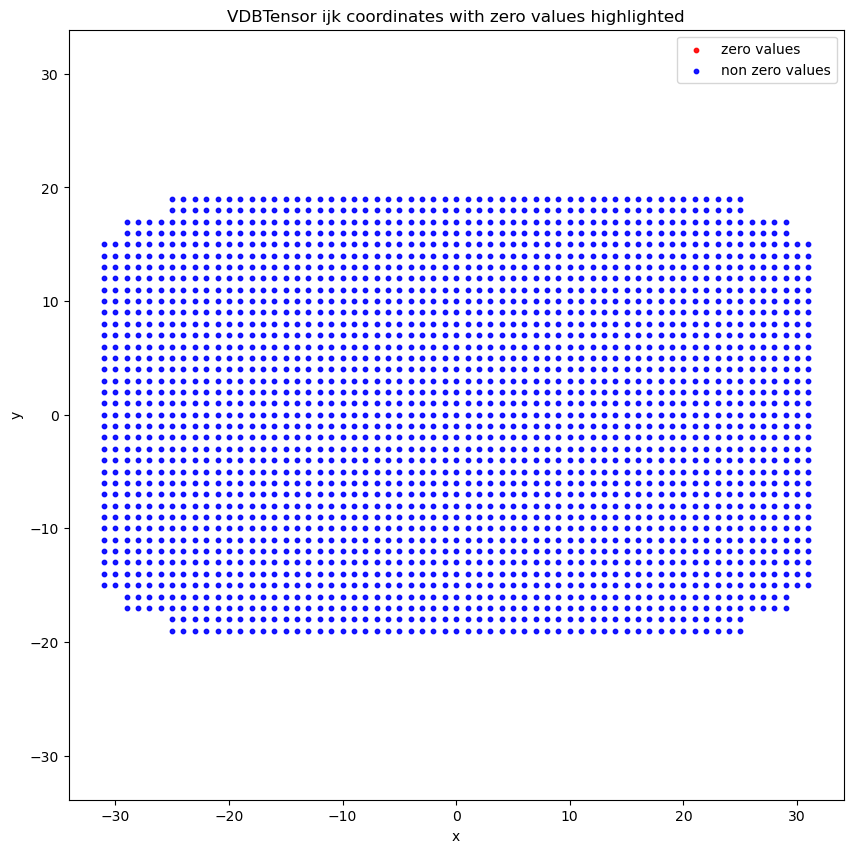

In [57]:
# for transformed_new_vdb
zero_mask = transformed_new_vdb.jdata == 0.0
# print((zero_mask.detach().cpu().nusmall_vdbmpy()==True).sum())
# Get the ijk coordinates as a numpy array
ijk = transformed_new_vdb.grid.ijk.jdata.cpu().numpy()
print(ijk)
plt.figure(figsize=(10, 10))
plt.scatter(
    ijk[zero_mask.cpu().numpy().squeeze()][:,0],
    ijk[zero_mask.cpu().numpy().squeeze()][:,1],
    c='red', s=10, alpha=0.9, marker='o', label='zero values'
)
plt.scatter(
    ijk[~zero_mask.cpu().numpy().squeeze()][:, 0],
    ijk[~zero_mask.cpu().numpy().squeeze()][:,1],
    c='blue', s=10, alpha=0.9, marker='o', label='non zero values'
)
plt.title('VDBTensor ijk coordinates with zero values highlighted')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()

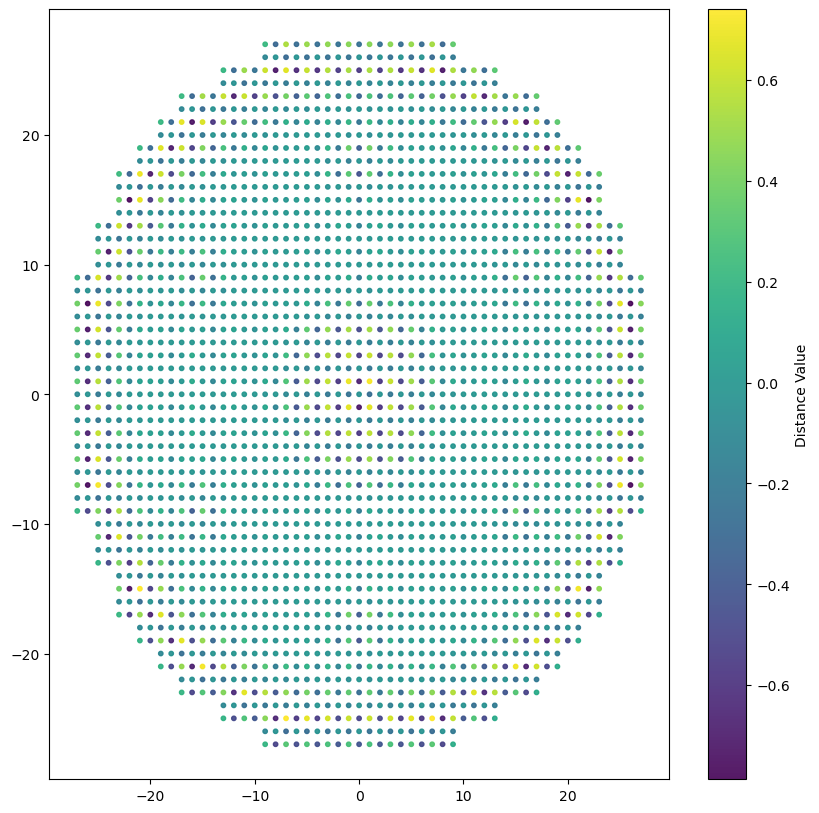

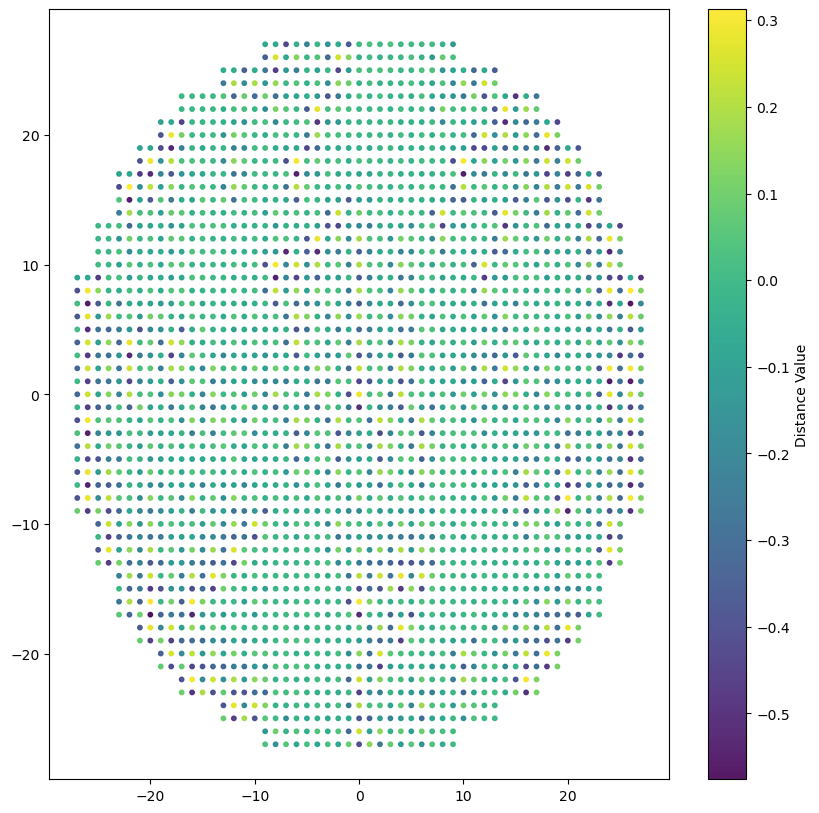

torch.Size([2481, 3])
torch.Size([2481, 3])


In [ ]:
# create transpose layer
cov_t = fvnn.SparseConv3d(
        in_channels=1, 
        out_channels=1, 
        kernel_size=3,
        stride=2,
        transposed=True,
        bias=False).to(device)
cov = fvnn.SparseConv3d(
        in_channels=1, 
        out_channels=1, 
        kernel_size=3,
        stride=1,
        # transposed=True,
        bias=False).to(device)
vdb_exp = cov_t(new_vdb, new_large_vdb.grid)
vdb_exp2 = cov(new_vdb2, new_large_vdb.grid)
with torch.no_grad():
    cov_t.weight.fill_(1.0)
    cov.weight.fill_(1.0)
    
plt.figure(figsize=(10, 10))    
plt.scatter(vdb_exp.grid.ijk.jdata[:, 0].cpu().numpy(), 
            vdb_exp.grid.ijk.jdata[:, 1].cpu().numpy(), 
            c=vdb_exp.jdata.detach().cpu().numpy().flatten(),  # Use voxel values as color
            cmap='viridis',  # Or any colormap you like
            s=10,
            alpha=0.9,  
            marker='o')
plt.colorbar(label='Distance Value')
plt.show()

plt.figure(figsize=(10, 10))    
plt.scatter(vdb_exp2.grid.ijk.jdata[:, 0].cpu().numpy(), 
            vdb_exp2.grid.ijk.jdata[:, 1].cpu().numpy(), 
            c=vdb_exp2.jdata.detach().cpu().numpy().flatten(),  # Use voxel values as color
            cmap='viridis',  # Or any colormap you like
            s=10,
            alpha=0.9,  
            marker='o')
plt.colorbar(label='Distance Value')
plt.show()
print(vdb_exp.grid.ijk.jdata.shape)
print(new_large_vdb.grid.ijk.jdata.shape)

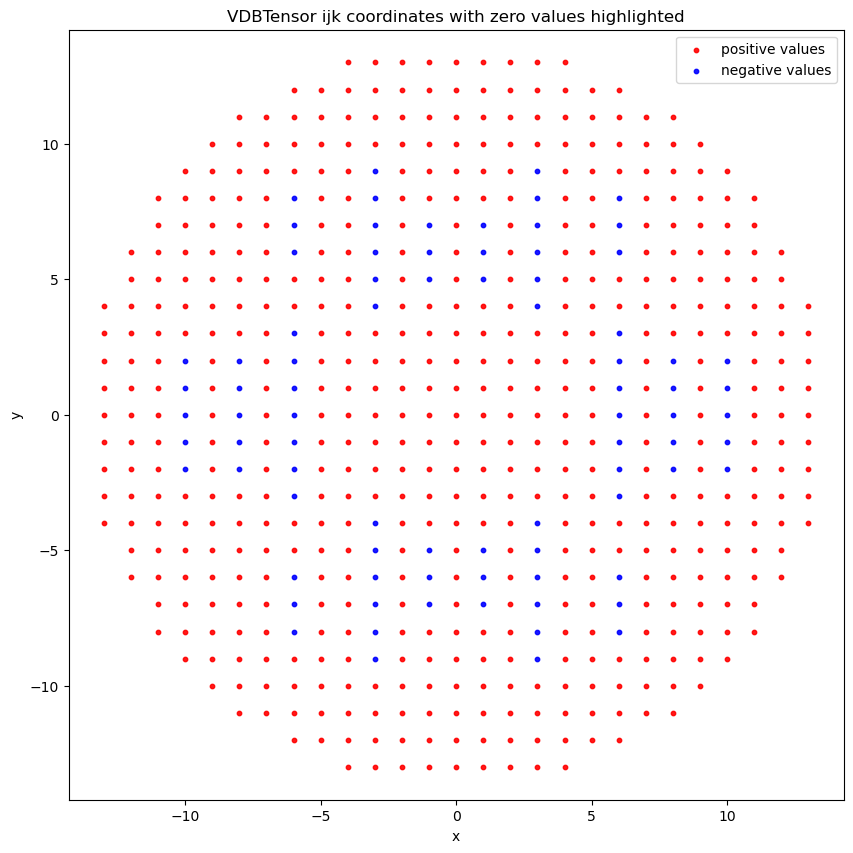

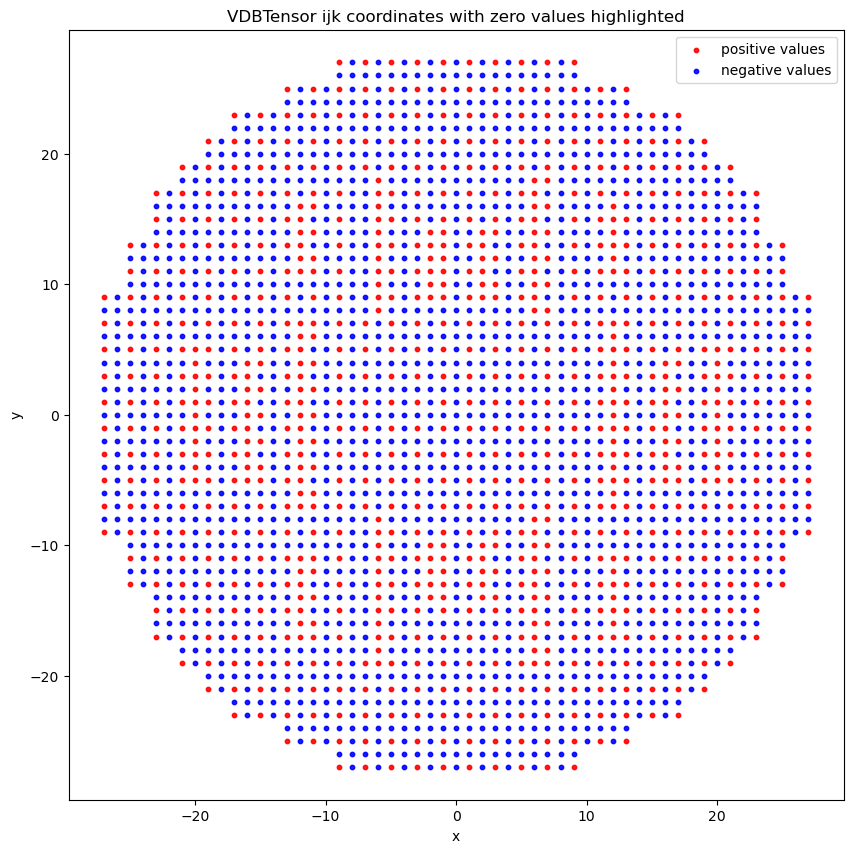

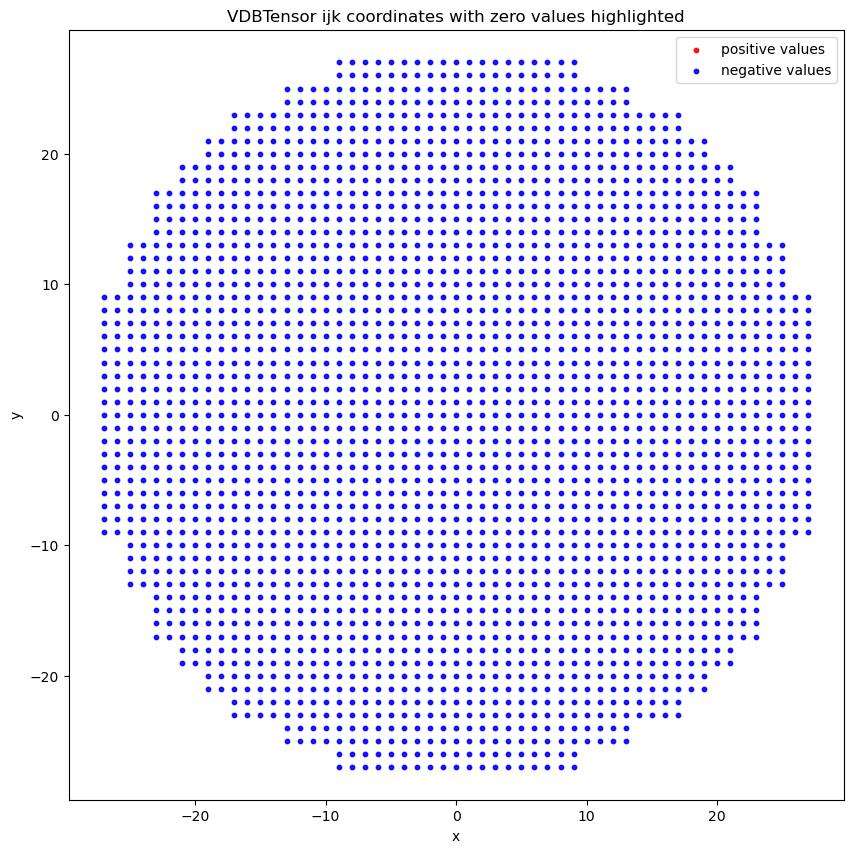

In [ ]:
# for new_vdb
zero_mask = new_vdb.jdata >= 0
# print((zero_mask.detach().cpu().numpy()==True).sum())
# Get the ijk coordinates as a numpy array
ijk = new_vdb.grid.ijk.jdata.cpu().numpy()
plt.figure(figsize=(10, 10))
plt.scatter(
    ijk[zero_mask.cpu().numpy().squeeze()][:,0],
    ijk[zero_mask.cpu().numpy().squeeze()][:,1],
    c='red', s=10, alpha=0.9, marker='o', label='positive values'
)
plt.scatter(
    ijk[~zero_mask.cpu().numpy().squeeze()][:, 0],
    ijk[~zero_mask.cpu().numpy().squeeze()][:,1],
    c='blue', s=10, alpha=0.9, marker='o', label='negative values'
)
plt.title('VDBTensor ijk coordinates with zero values highlighted')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()

# for new_large_vdb
# zero_mask = new_large_vdb.jdata >= 0
# # print((zero_mask.detach().cpu().numpy()==True).sum())
# # Get the ijk coordinates as a numpy array
# ijk = new_large_vdb.grid.ijk.jdata.cpu().numpy()
# plt.figure(figsize=(10, 10))
# plt.scatter(
#     ijk[zero_mask.cpu().numpy().squeeze()][:,0],
#     ijk[zero_mask.cpu().numpy().squeeze()][:,1],
#     c='red', s=10, alpha=0.9, marker='o', label='positive values'
# )
# plt.scatter(
#     ijk[~zero_mask.cpu().numpy().squeeze()][:, 0],
#     ijk[~zero_mask.cpu().numpy().squeeze()][:,1],
#     c='blue', s=10, alpha=0.9, marker='o', label='negative values'
# )
# plt.title('VDBTensor ijk coordinates with zero values highlighted')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.axis('equal')
# plt.legend()
# plt.show()

# for vdb_exp
zero_mask = vdb_exp.jdata >= 0
# print((zero_mask.detach().cpu().numpy()==True).sum())
# Get the ijk coordinates as a numpy array
ijk = vdb_exp.grid.ijk.jdata.cpu().numpy()
plt.figure(figsize=(10, 10))
plt.scatter(
    ijk[zero_mask.cpu().numpy().squeeze()][:,0],
    ijk[zero_mask.cpu().numpy().squeeze()][:,1],
    c='red', s=10, alpha=0.9, marker='o', label='positive values'
)
plt.scatter(
    ijk[~zero_mask.cpu().numpy().squeeze()][:, 0],
    ijk[~zero_mask.cpu().numpy().squeeze()][:,1],
    c='blue', s=10, alpha=0.9, marker='o', label='negative values'
)
plt.title('VDBTensor ijk coordinates with zero values highlighted')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()

# for vdb_exp2
zero_mask = vdb_exp2.jdata >= 0
# print((zero_mask.detach().cpu().numpy()==True).sum())
# Get the ijk coordinates as a numpy array
ijk = vdb_exp2.grid.ijk.jdata.cpu().numpy()
plt.figure(figsize=(10, 10))            
plt.scatter(
    ijk[zero_mask.cpu().numpy().squeeze()][:,0],
    ijk[zero_mask.cpu().numpy().squeeze()][:,1],
    c='red', s=10, alpha=0.9, marker='o', label='positive values'
)
plt.scatter(
    ijk[~zero_mask.cpu().numpy().squeeze()][:, 0],
    ijk[~zero_mask.cpu().numpy().squeeze()][:,1],
    c='blue', s=10, alpha=0.9, marker='o', label='negative values'
)
plt.title('VDBTensor ijk coordinates with zero values highlighted')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()